# Metody analizy sieci złożonych - zadanie nr 1

## Zadanie 1, część 1

Zadanie realizowane jest z użyciem Neo4j Desktop na danych ASOIAF z repozytorium Konect. Źródło danych: http://konect.cc/networks/asoiaf/. Każdy wierzchołek reprezentuje postać z sagi, krawędzie łączą postacie wzmiankowane razem w tekście.

### Krok 1-5 – Instalacja Neo4j, utworzenie bazy, włączenie pluginów

1. Zainstalowano Neo4j Desktop zgodnie z instrukcją.
2. Utworzono nową instancję bazy danych (podano nazwę i hasło).
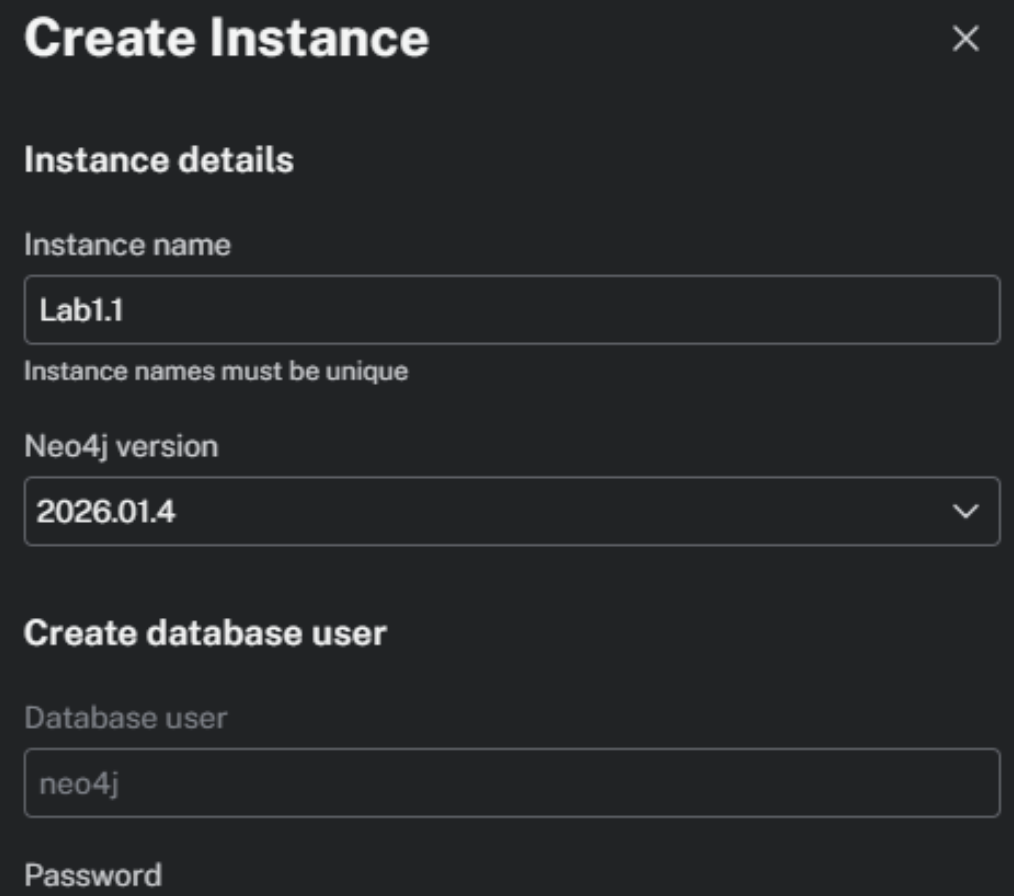
3. Włączono pluginy **APOC** oraz **Graph Data Science (GDS)**.
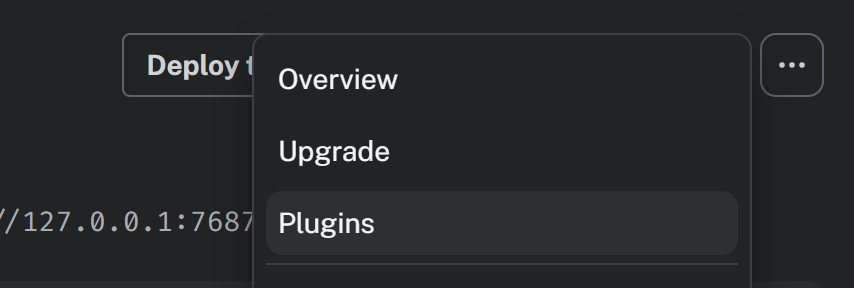
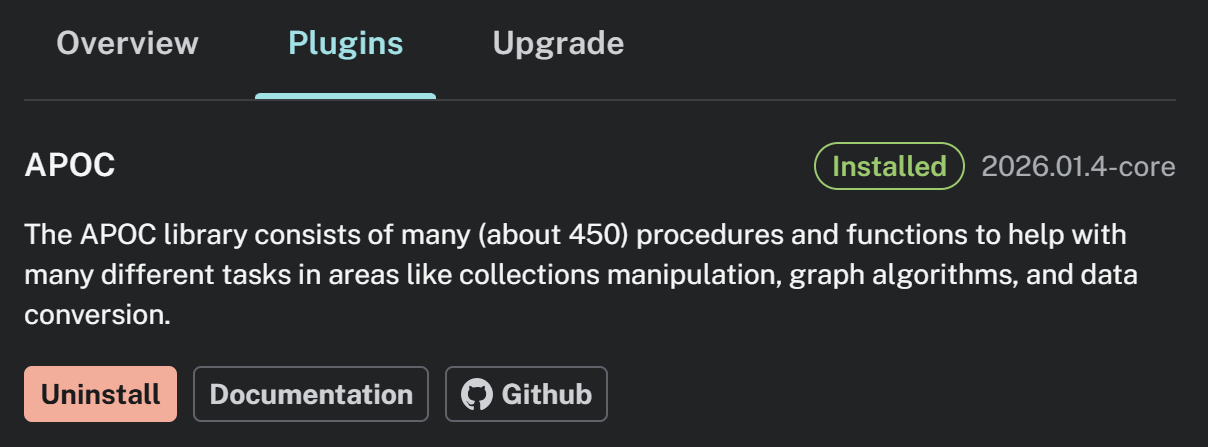
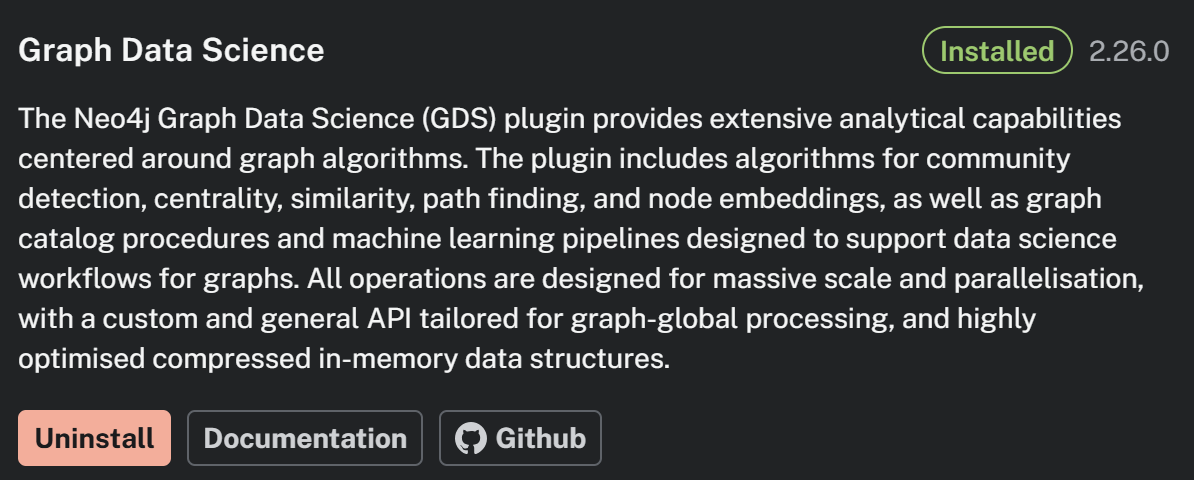
4. Połączono się z bazą i zapoznano z interfejsem zakładki **Query**.
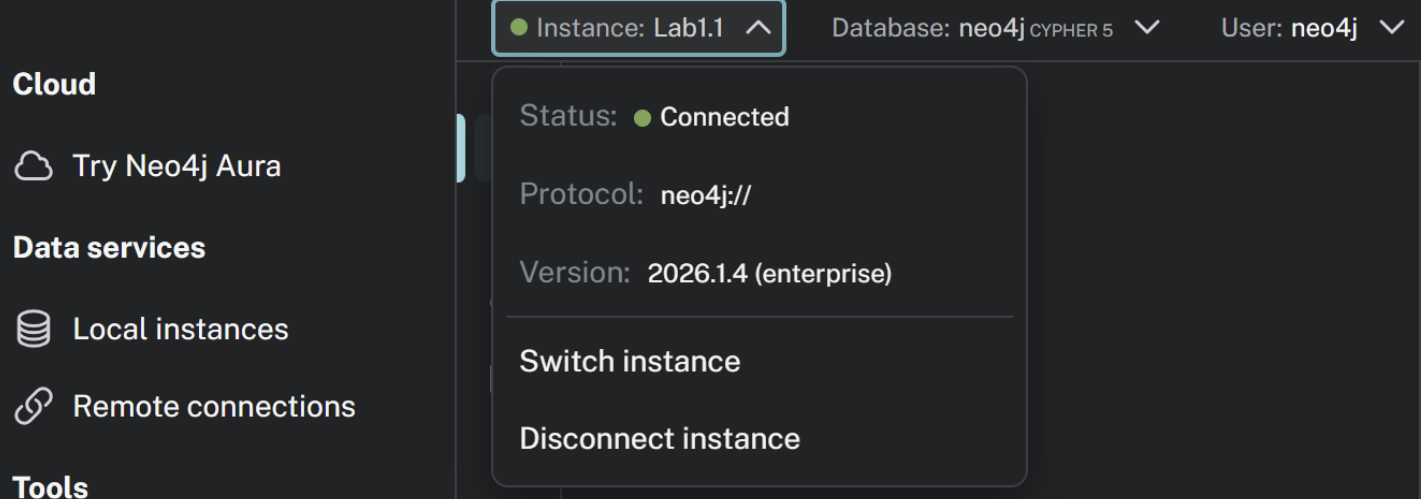
- Query znajduje się w pasku bocznym Desktop, w sekcji Tools. Połączenie z instancją można nawiązać przez dropdown połączeń lub bezpośrednio z karty instancji (opcja Connect tools), a następnie wybrać konkretną bazę danych.
- Pasek boczny (Sidebar)
    - Database information – liczba węzłów i relacji, ich etykiety i typy, lista kluczy właściwości.
    - Saved Cypher – zapisane zapytania; można je klikając załadować do edytora, pobierać, wgrywać i usuwać.
    - History – pełna historia wszystkich wykonanych zapytań (niezależnie od bazy czy instancji).
    - Cypher Reference – podręczny przewodnik po języku Cypher dostępny bez wychodzenia z aplikacji.
    - Parameters – ustawianie parametrów dla większości typów właściwości Neo4j.
- Edytor Cypher – pole do wpisywania i uruchamiania zapytań; można otworzyć wiele edytorów jednocześnie, zapisywać zapytania i formatować kod.
- Ramki wyników – wielokrotnego użytku; wynik można edytować i odświeżać w miejscu. Dostępne widoki: Graph, Table, RAW.

### Krok 6 – Przygotowanie pliku `asoiaf.csv`

Plik został przygotowany za pomocą skryptu napisanego w Python, gdzie został stworzony plik asoiaf.csv w oparciu o out.asoiaf gdzie usunięto pierwszy wiersz, trzecią kolumnę oraz zamieniono spacje na przecinki
```python
import csv

input_file = 'out.asoiaf'
output_file = 'asoiaf.csv'

with open(input_file, "r") as f_in, open(output_file, 'w', newline='') as f_out:
    next(f_in)

    writer = csv.writer(f_out)
    for row in f_in:
        columns = row.strip().split()
        if len(columns) >= 3:
            del columns[2]
            writer.writerow(columns)
```

### Krok 7-8 – Import danych do Neo4j

7. W folderze instacji utworzono folder `import` gdzie umieszczono 'asoiaf.csv'
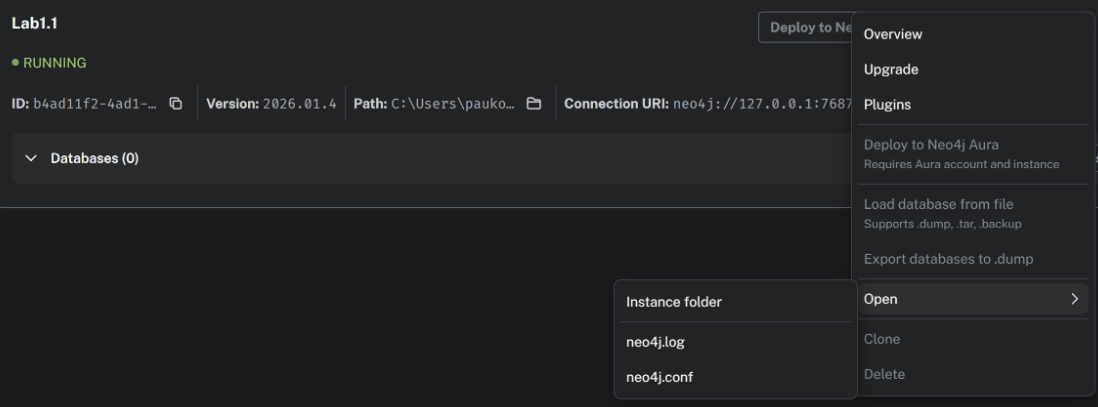
8. Wykonano Cypher Query do zaimportowania danych
- Ograniczenie unikalności węzłów
    ```
    CREATE CONSTRAINT character_id
    IF NOT EXISTS FOR (c:Character)
    REQUIRE c.id IS UNIQUE;
    ```
- Import krawędzi z pliku CSV
    ```
    LOAD CSV FROM 'file:///asoiaf.csv' AS row
    WITH toInteger(row[0]) AS src, toInteger(row[1]) AS dst
    MERGE (a:Character {id: src})
    MERGE (b:Character {id: dst})
    MERGE (a)-[:INTERACTS_WITH]->(b)
    MERGE (b)-[:INTERACTS_WITH]->(a);
    ```

### Krok 9 – Wizualizacja grafu w sekcji Explore

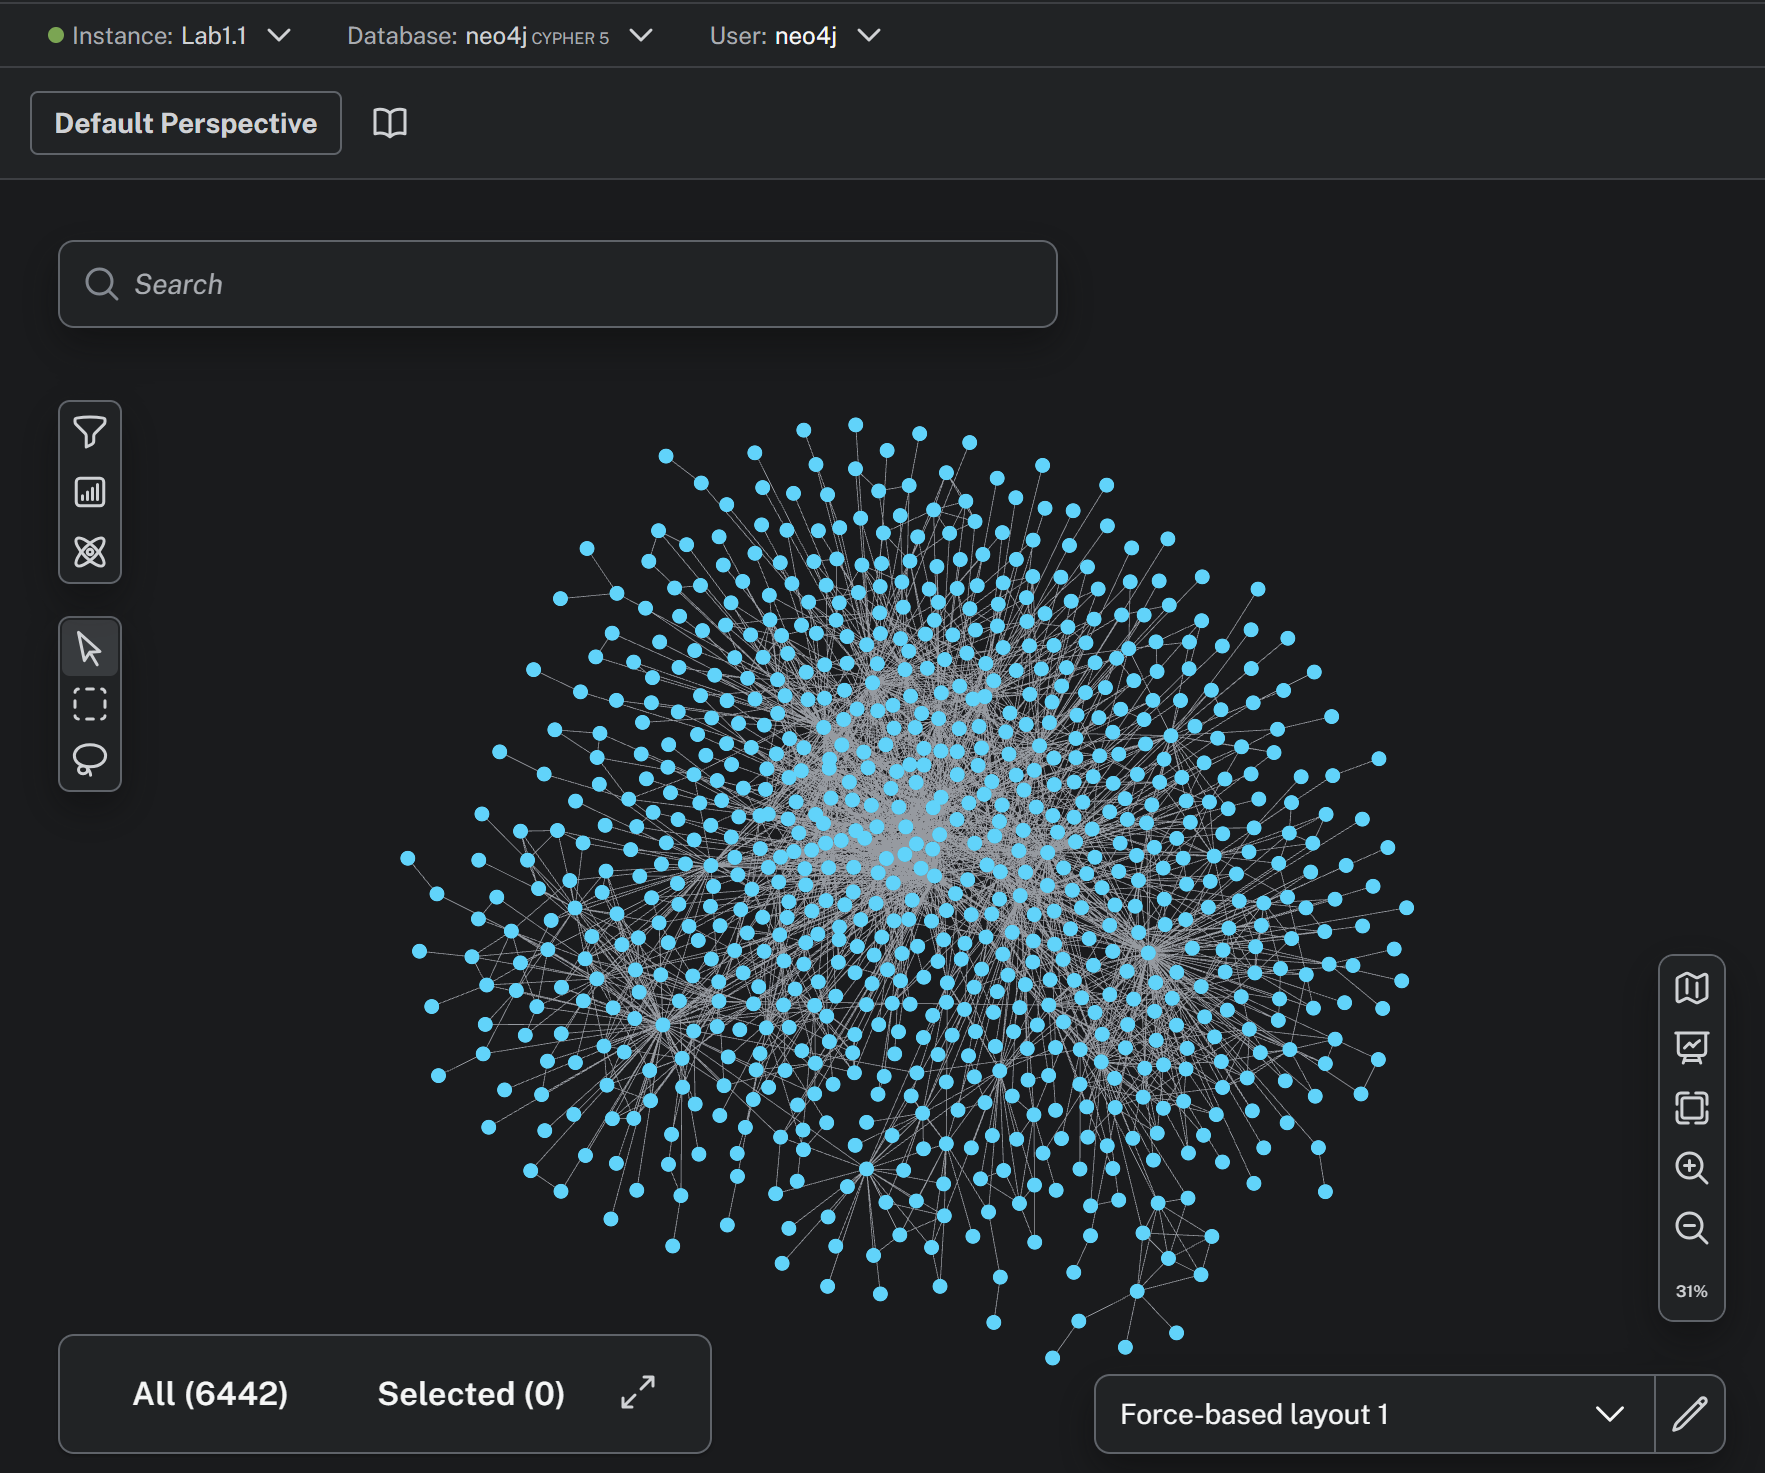
W ustawieniach Explore zwiększono limit wyświetlanych węzłów do odpowiedniej wartości dla tej sieci.

### Krok 10 – Algorytmy Graph Data Science
- Degree Centrality
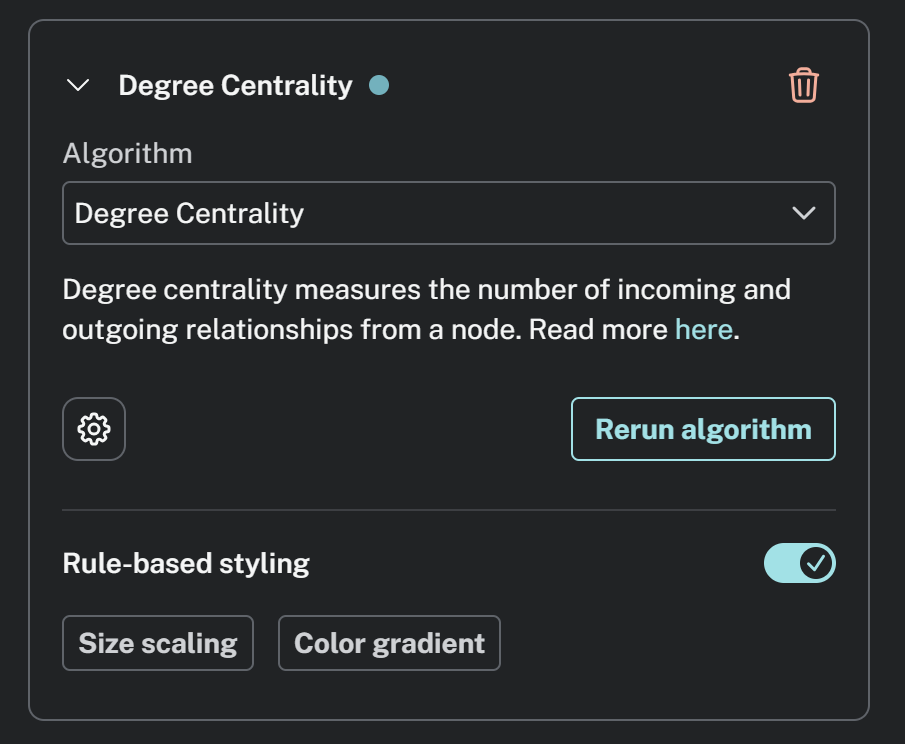
- PageRank
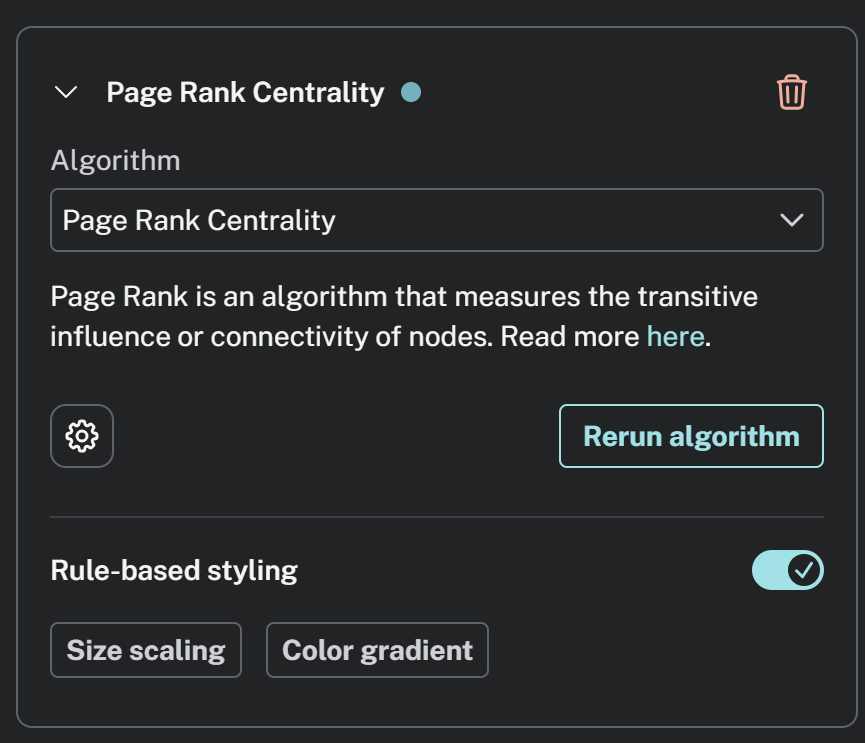

### Krok 11 – Styl PageRank i eksport screenshota

Zastosowano styl graficzny uzależniający rozmiar węzła od wartości PageRank oraz wyeksportowano screenshota
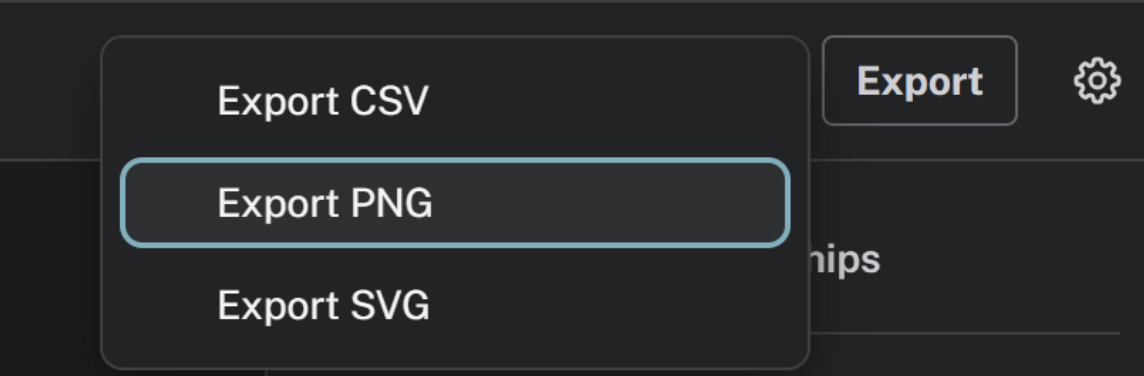
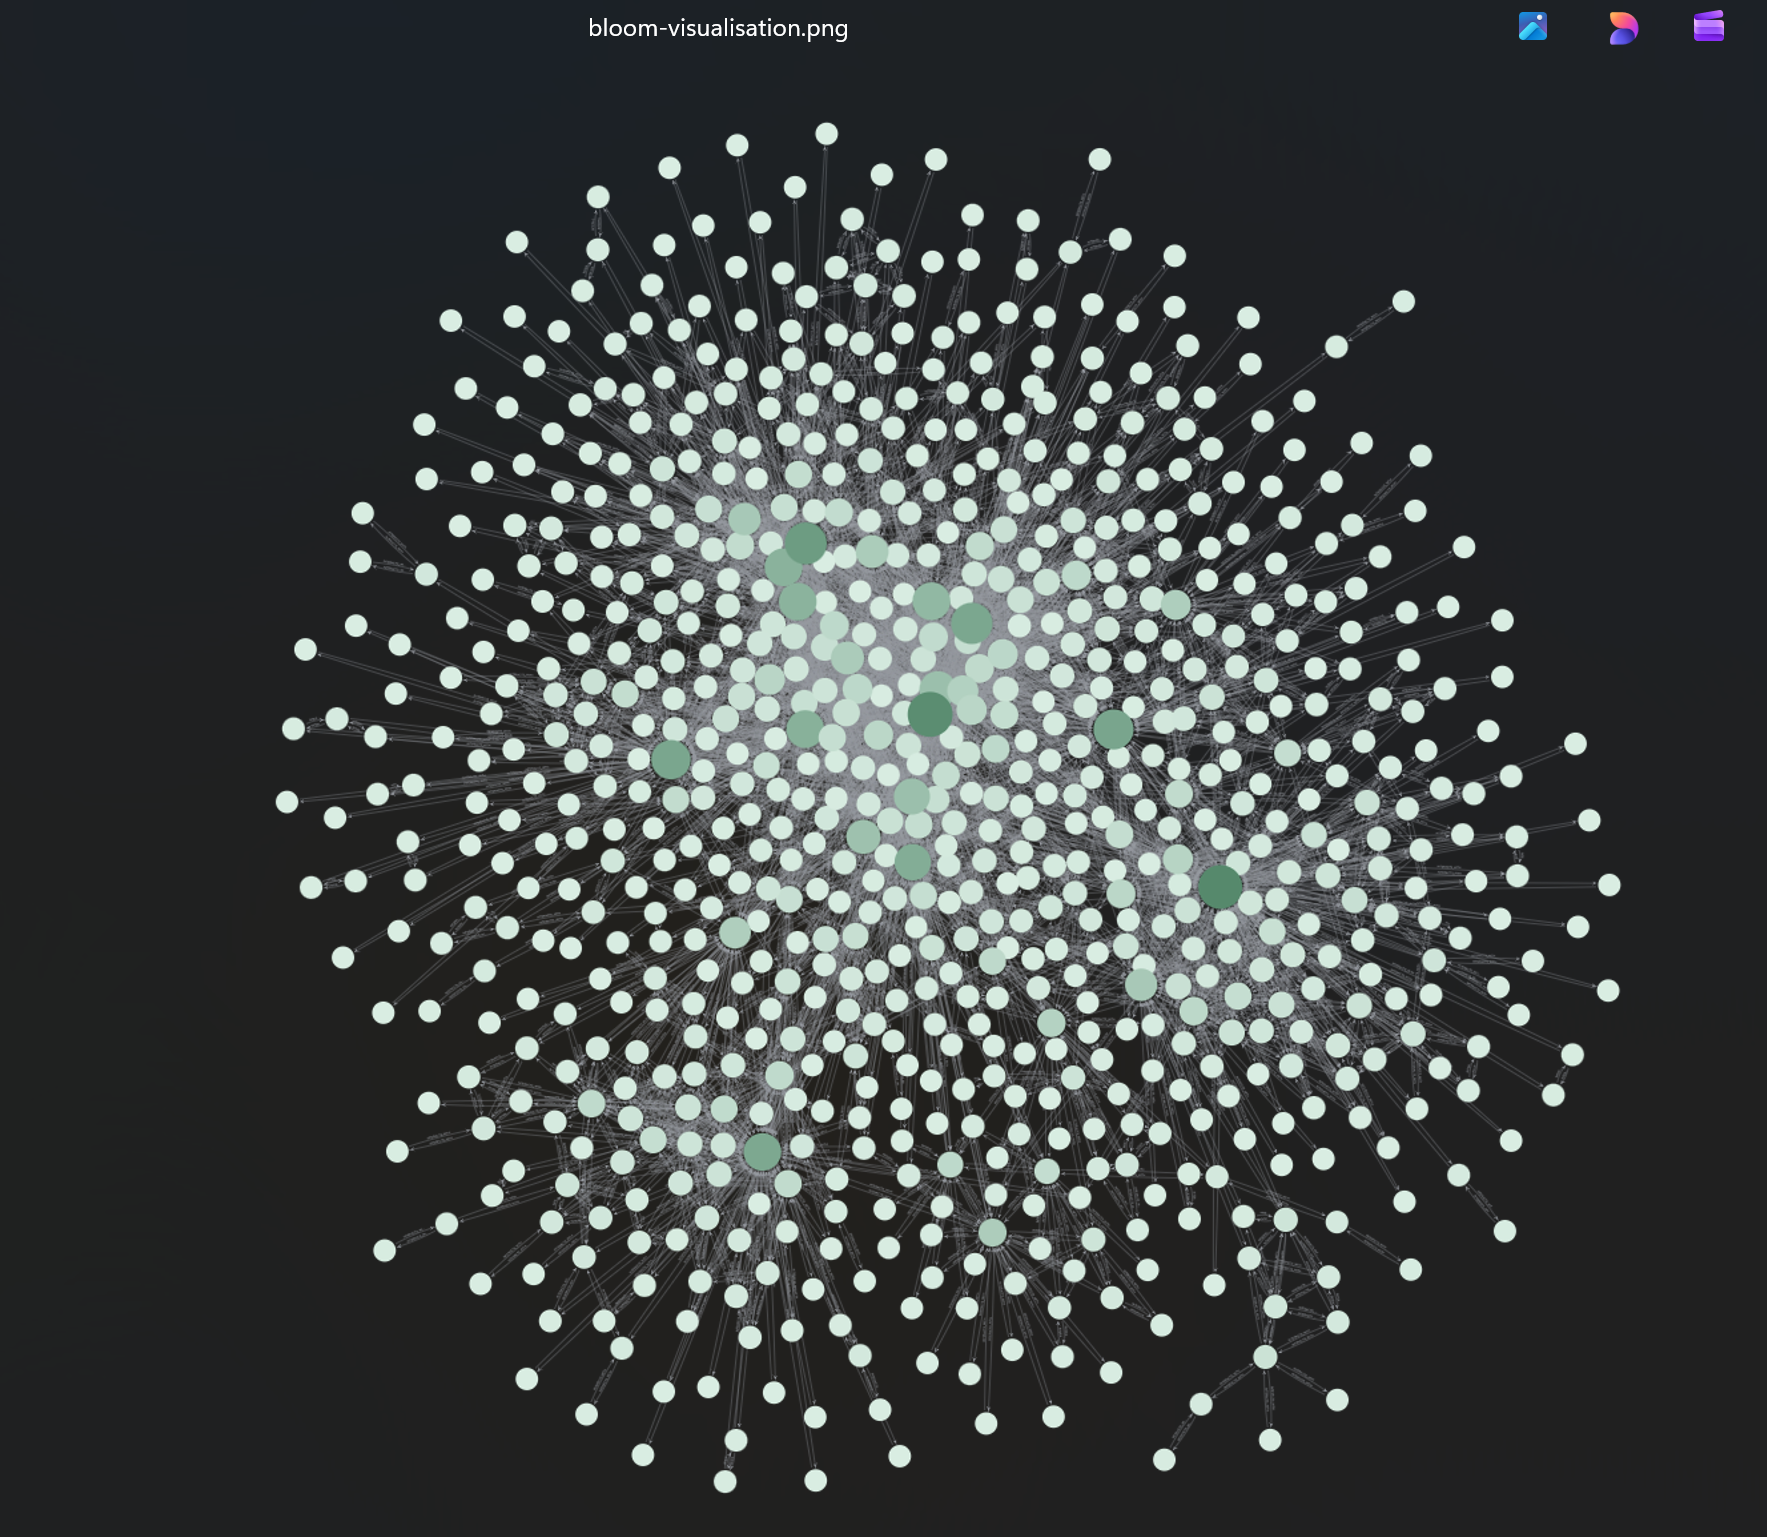

### Krok 12 – Węzeł z najwyższą centralnością

Za pomocą zastosowanych stylów graficznych w kroku wcześniejszym oraz metodzie `Inspect` odnaleziono węzeł z najwyższą centralnością.
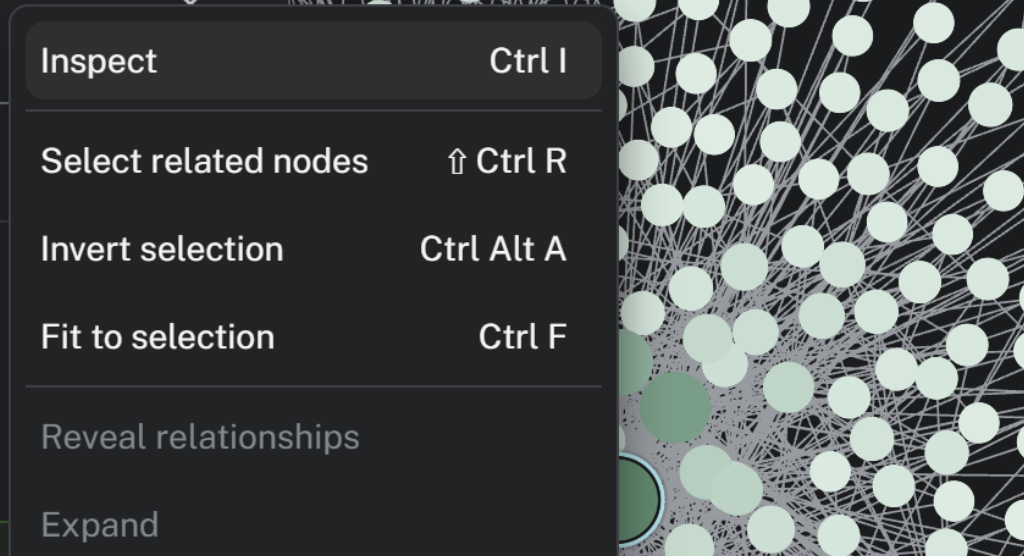
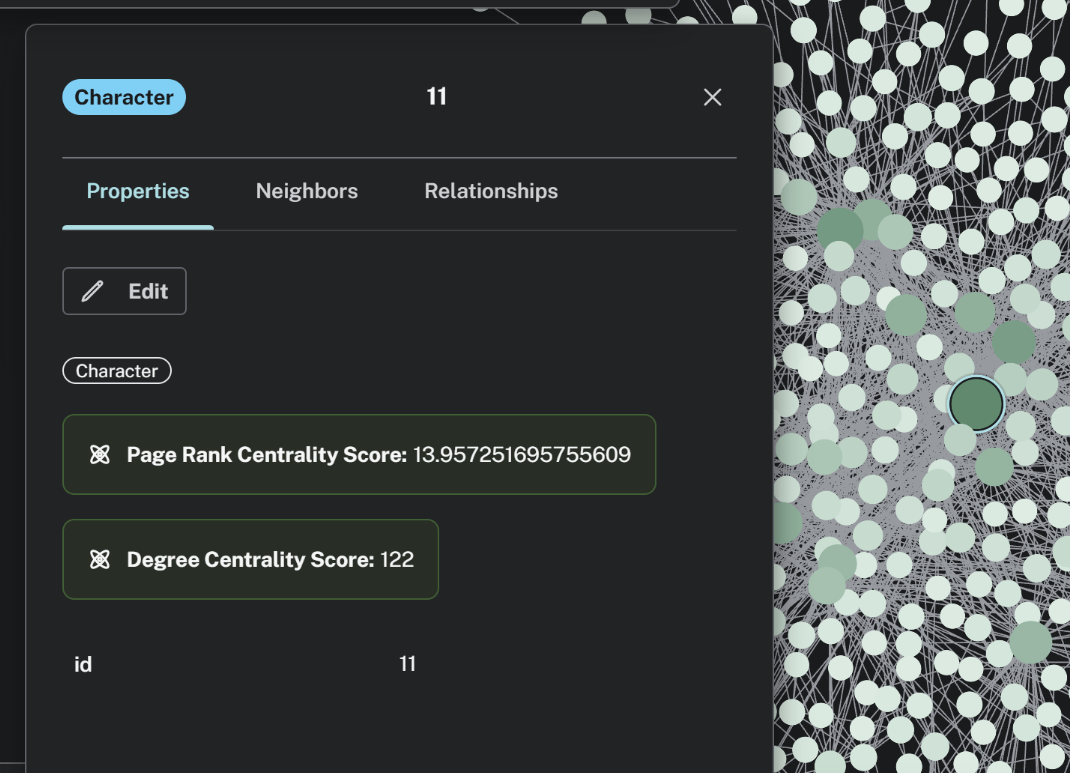

### Krok 13 – Filtrowanie: węzły o stopniu > 12 (Slicer)

Zastosowano slicer w zakładce Explore ograniczając widok do wierzchołków o `degree < 12`.
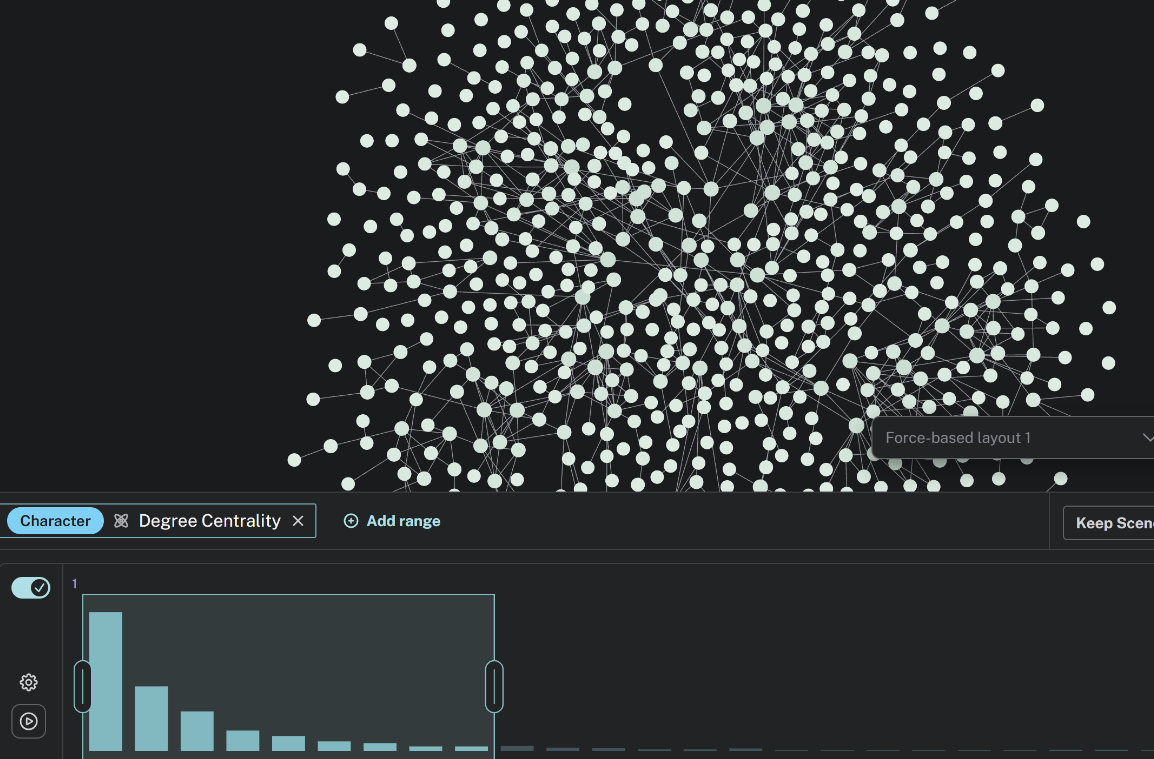

### Dyskusja po Części 1
- **Czytelność i intuicyjność Neo4j Desktop**
    - Interfejs Neo4j Desktop jest stosunkowo intuicyjny – zakładki Query i Explore są logicznie podzielone, jednak prawidłowe umieszczenie danych w odpowiednim folderze może być mylące.
- **Responsywność i szybkość**
    - Wykonywanie zapytań Cypher było szybkie dla tej wielkości sieci. Wizualizacja w Explore przy dużej liczbie węzłów potrafi być wolniejsza i wymaga dostosowania limitów wyświetlania.
- **Zmiana layoutu (hierarchical / force-based / circular)**
    - Tak – zmiana layoutu istotnie wpływa na percepcję struktury. Layout force-based najlepiej eksponuje klastry i huby, circular ułatwia identyfikację węzłów peryferyjnych, a hierarchical sugeruje strukturę drzewiastą, która nie jest naturalna dla tej sieci.

## Zadanie 1, część 2 - NetworkX: Analiza numeryczna sieci

W części drugiej zadania były wykonywane za pomocą uwtorzonych klas: `MyGraph` oraz `ImportGraph`

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import kendalltau


class MyGraph:
    def __init__(self, nodes: int = None, probability: float = None, edges_per_node: int = None, G: nx.Graph = None):
        if G is None:
            if edges_per_node is None:
                self.G = nx.erdos_renyi_graph(n=nodes, p=probability)
            else:
                self.G = nx.barabasi_albert_graph(n=nodes, m=edges_per_node)
        else:
            self.G = G

    def _get_simple_graph(self):
        if isinstance(self.G, nx.MultiGraph):
            return nx.Graph(self.G)
        return self.G

    def plot_graph(self, if_pagerank: bool = False):
        simple_graph = self._get_simple_graph()
        plt.figure(figsize=(12, 8))
        pos = nx.kamada_kawai_layout(simple_graph)
        nodes_size = []
        if if_pagerank:
            pagerank = nx.pagerank(simple_graph)
            nodes_size = [pagerank[node] * 40000 for node in simple_graph.nodes()]
        nx.draw_networkx(
            simple_graph,
            pos=pos,
            with_labels=True,
            node_color="lightblue",
            node_size=nodes_size if if_pagerank else 30,
            edge_color="gray",
            alpha=0.7
        )
        plt.tight_layout()
        plt.show()

    def print_info(self, text: bool = True):
        nodes = self.G.nodes()
        nodes_num = len(nodes)
        edges = self.G.edges()
        edges_num = len(edges)

        print("Nodes:", nodes) if text else None
        print(f"Nodes number: {nodes_num}")
        print("Edges:", edges) if text else None
        print(f"Edges number: {edges_num}")

    def plot_degree(self):
        simple_graph = self._get_simple_graph()
        degree_values = [deg for _, deg in simple_graph.degree()]

        plt.figure(figsize=(10, 6))
        sns.histplot(
            degree_values,
            bins=25,
            kde=True,
            color="steelblue",
            edgecolor="white",
            linewidth=0.5
        )
        plt.title("Degree Distribution", fontsize=14)
        plt.xlabel("Degree")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    def plot_betweenness_centrality(self):
        simple_graph = self._get_simple_graph()
        betweenness = nx.betweenness_centrality(simple_graph)
        betweenness_values = list(betweenness.values())
        plt.figure(figsize=(10, 6))
        sns.histplot(betweenness_values, bins=25, kde=True, color="steelblue", edgecolor="white", linewidth=0.5)
        plt.title("Betweenness Centrality Distribution", fontsize=14)
        plt.xlabel("Betweenness")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    def plot_closeness_centrality(self):
        simple_graph = self._get_simple_graph()
        closeness = nx.closeness_centrality(simple_graph)
        closeness_values = list(closeness.values())
        plt.figure(figsize=(10, 6))
        sns.histplot(closeness_values, bins=25, kde=True, color="steelblue", edgecolor="white", linewidth=0.5)
        plt.title("Closeness Centrality Distribution", fontsize=14)
        plt.xlabel("Closeness")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    def betweenness_centrality(self):
        return nx.betweenness_centrality(self._get_simple_graph())

    def max_betweenness_centrality(self):
        betweeness = self.betweenness_centrality()
        return max(betweeness, key=betweeness.get)

    def closeness_centrality(self):
        return nx.closeness_centrality(self._get_simple_graph())

    def clustering_coefficient(self):
        return nx.clustering(self._get_simple_graph())

    def pagerank(self):
        return nx.pagerank(self._get_simple_graph())

    def connected_components(self):
        return nx.number_connected_components(self._get_simple_graph())

    def density(self):
        return nx.density(self._get_simple_graph())

    def nodes_without_edges(self):
        return len([node for node,degree in dict(self.G.degree()).items() if degree == 0])

    def get_dataframe(self) -> pd.DataFrame:
        simple_graph = self._get_simple_graph()
        betweeness = self.betweenness_centrality()
        closeness = self.closeness_centrality()
        clustering = self.clustering_coefficient()
        pagerank = self.pagerank()

        diameter, avg_shortest_path = self.diameter_and_shortest_path_length()
        num_components = nx.number_connected_components(simple_graph)

        df = pd.DataFrame({
            "betweenness": pd.Series(betweeness),
            "closeness": pd.Series(closeness),
            "clustering": pd.Series(clustering),
            "pagerank": pd.Series(pagerank),
            "avg_shortest_path": avg_shortest_path,
            "diameter": diameter,
            "num_components": num_components,
        })
        return df

    def remove_duplicate_edges(self):
        self.G.remove_edges_from(nx.selfloop_edges(self.G))

        if isinstance(self.G, nx.MultiGraph):
            set_list = [set(a) for a in self.G.edges()]
            remove_list = []

            for i in range(len(set_list)):
                edge = set_list.pop(0)
                if set_list.count(edge) > 0:
                    u, v = edge
                    remove_list.append((v, u))

            self.G.remove_edges_from(remove_list)
            self.G = nx.Graph(self.G)

    def kendall(self):
        simple_graph = self._get_simple_graph()

        degree = list(dict(nx.degree(simple_graph)).values())
        betweeness = list(nx.betweenness_centrality(simple_graph).values())
        closeness = list(nx.closeness_centrality(simple_graph).values())

        ken_deg_bet, _ = kendalltau(degree, betweeness)
        ken_deg_close, _ = kendalltau(degree, closeness)
        ken_bet_close, _ = kendalltau(betweeness, closeness)

        print("Korelacja Kendall τ:")
        print("degree vs betweenness:", ken_deg_bet)
        print("degree vs closeness:", ken_deg_close)
        print("betweenness vs closeness:", ken_bet_close)

    def top_nodes(self):
        simple_graph = self._get_simple_graph()
        n = 5

        degree = dict(nx.degree(simple_graph))
        betweeness = nx.betweenness_centrality(simple_graph)
        closeness = nx.closeness_centrality(simple_graph)

        print("Top degree:")
        print(sorted(degree, key=degree.get, reverse=True)[:n])
        print("Top betweenness:")
        print(sorted(betweeness, key=betweeness.get, reverse=True)[:n])
        print("Top closeness:")
        print(sorted(closeness, key=closeness.get, reverse=True)[:n])

    def diameter_and_shortest_path_length(self):
        simple_graph = self._get_simple_graph()
        largest_cc = max(nx.connected_components(simple_graph), key=len)
        G_largest = simple_graph.subgraph(largest_cc)

        avg_shortest_path = nx.average_shortest_path_length(G_largest)
        diameter = nx.diameter(G_largest)
        return diameter, avg_shortest_path

    def if_strongly_connected(self):
        if self.G.is_directed():
            return nx.is_strongly_connected(self.G)
        return None

In [2]:
import networkx as nx
import pandas as pd
from networkx import DiGraph
from networkx.classes import MultiGraph

class ImportGraph:
    @staticmethod
    def get_radoslaw_from_file(directed: bool = False) -> MyGraph:
        input_file = 'out.radoslaw_email_email'
        df = pd.read_csv(
            input_file,
            sep=r"\s+",
            skiprows=2,
            usecols=[0, 1],
            names=['sender', 'receiver'],
            header=None
        )
        if directed:
            edge_counts = df.groupby(['sender', 'receiver']).size().reset_index(name='edge_count')
            total_counts = df.groupby(['sender']).size().reset_index(name='total_count')
            edge_weights = edge_counts.merge(total_counts, on=['sender'])
            edge_weights['weight'] = edge_weights['edge_count'] / edge_weights['total_count']
            G = DiGraph()

            for _, row in edge_weights.iterrows():
                G.add_edge(row['sender'], row['receiver'], weight=row['weight'])
        else:
            edges = df.values
            G = nx.MultiGraph()
            G.add_edges_from(edges)
        return MyGraph(G=G)

### 1. Grafy losowe (model Erdős-Rényi)

(a,b) Wygenerowano sieć Erdős-Rényi o N = 100 i p = 0.05 oraz wylistowano wszystkie wierzchołki i krawędzie

In [3]:
G_er = MyGraph(nodes=100, probability=0.05)
G_er.print_info()

Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Nodes number: 100
Edges: [(0, 20), (0, 49), (0, 86), (0, 94), (1, 61), (1, 71), (1, 79), (1, 95), (1, 97), (2, 42), (2, 55), (2, 59), (2, 64), (2, 70), (2, 77), (3, 23), (3, 51), (3, 61), (3, 88), (4, 8), (4, 12), (4, 21), (4, 23), (4, 35), (4, 52), (4, 65), (5, 40), (5, 64), (5, 79), (6, 7), (6, 67), (6, 84), (6, 97), (7, 25), (7, 73), (7, 97), (8, 37), (8, 77), (8, 93), (8, 94), (9, 19), (9, 80), (9, 88), (10, 13), (10, 17), (10, 45), (11, 26), (11, 53), (11, 70), (12, 44), (12, 61), (12, 68), (13, 17), (13, 19), (13, 65), (13, 66), (13, 85), (13, 86), (14, 15), (14, 32), (14, 50), (14, 65), (

(c) Obliczono stopień (degree) a następnie stworzono histogram

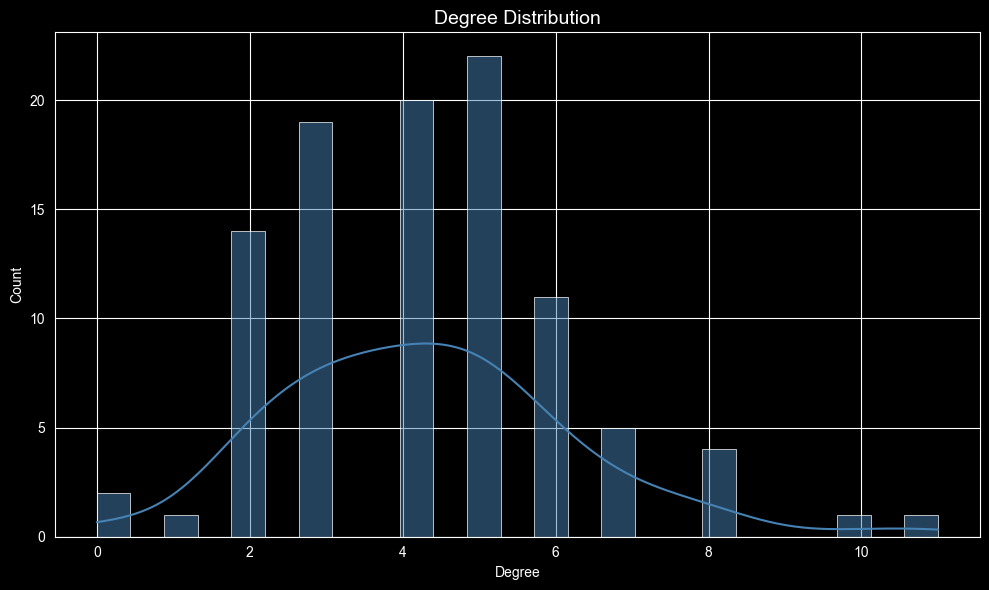

In [4]:
G_er.plot_degree()

(d) Przygotowano dataframe oraz jego opis statystyczny z wykorzystaniem funkcji describe.

In [5]:
df = G_er.get_dataframe()
print(df)
print(100*"-")
print(df.describe())

    betweenness  closeness  clustering  pagerank  avg_shortest_path  diameter  \
0      0.020986   0.305596    0.000000  0.009453            3.24069         6   
1      0.037658   0.343106    0.000000  0.011275            3.24069         6   
2      0.047156   0.362750    0.000000  0.012630            3.24069         6   
3      0.011305   0.300761    0.166667  0.009489            3.24069         6   
4      0.044782   0.335832    0.047619  0.014989            3.24069         6   
..          ...        ...         ...       ...                ...       ...   
95     0.030394   0.302676    0.000000  0.011632            3.24069         6   
96     0.012321   0.303643    0.000000  0.007447            3.24069         6   
97     0.075596   0.374175    0.035714  0.016813            3.24069         6   
98     0.000000   0.232373    0.000000  0.003774            3.24069         6   
99     0.014819   0.292432    0.000000  0.007785            3.24069         6   

    num_components  
0     

(e) Wyliczono ilość komponentów (connected components) w grafie

In [6]:
G_er.connected_components()

3

(f) Zwizualizowano graf w taki sposób, aby rozmiar węzłów odpowiadał mierze PageRank

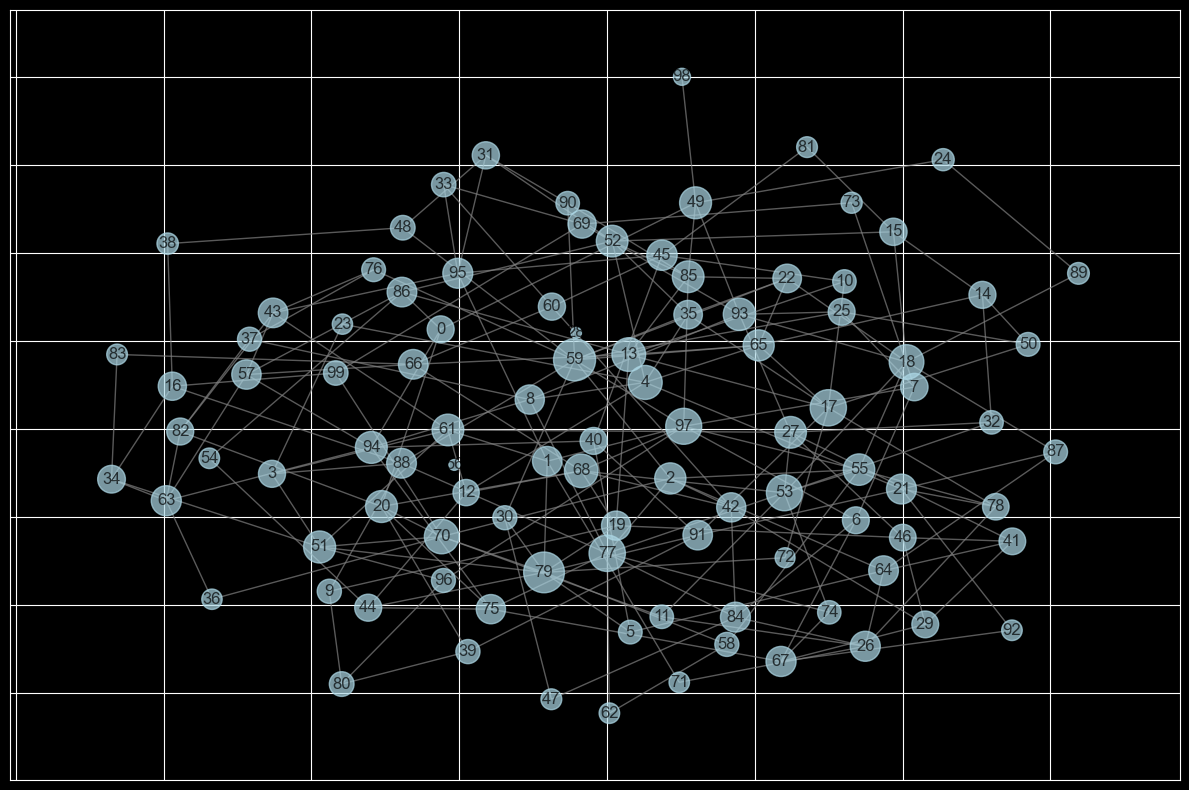

In [7]:
G_er.plot_graph(if_pagerank=True)

### 2. Sieci bezskalowe (model Barabási-Albert)

(a, b) Wygenerowano graf wedle modelu Barabási-Albert z N = 1000 i m0=m=3 i zwizualizowano go layoutem Kamada-Kawai

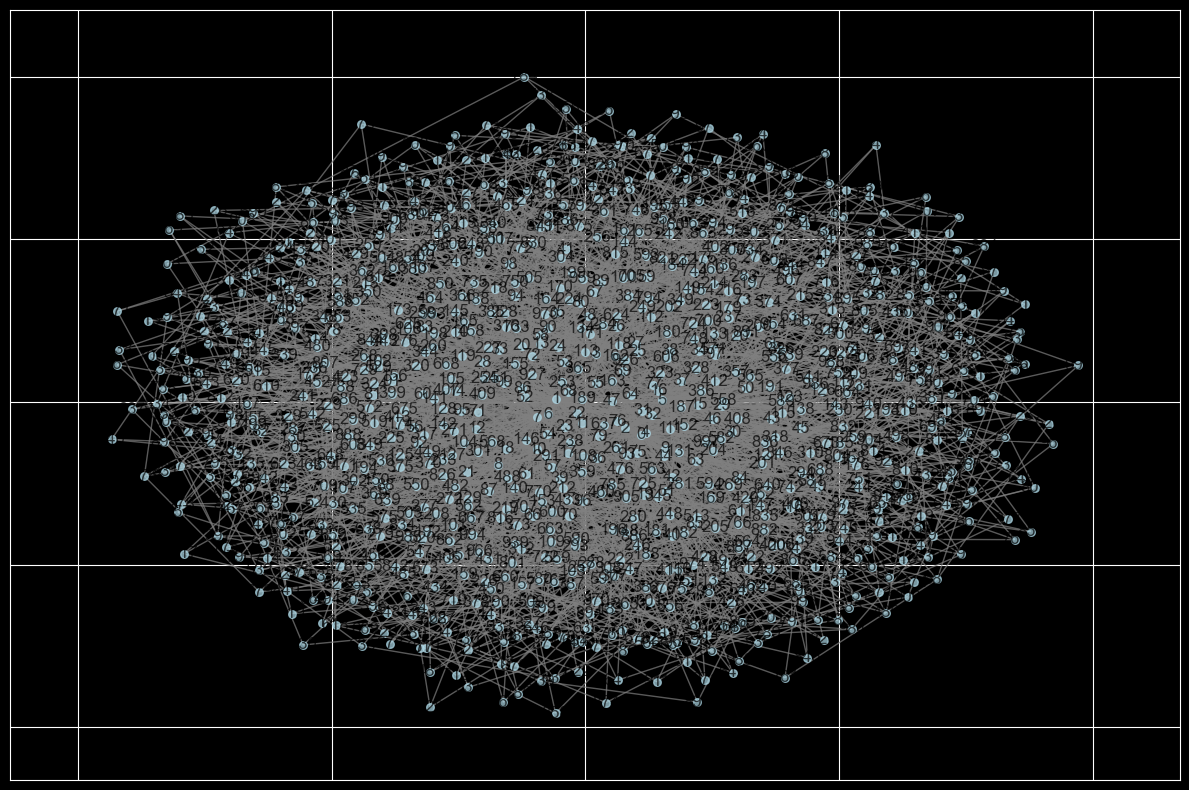

In [8]:
G_ba = MyGraph(nodes=1000, edges_per_node=3)
G_ba.plot_graph()

(c) Znaleziono id najbardziej centralnego węzła według miary pośrednictwa (betweenness)

In [9]:
G_ba.max_betweenness_centrality()

1

(d) Obliczono średnice grafu

In [10]:
diameter, _ = G_ba.diameter_and_shortest_path_length()
print(diameter)

6


(e) Zaobserwowano różnice pomiędzy

In [11]:
print("=== Erdős-Rényi ===")
G_er.print_info(text=False)
df_er = G_er.get_dataframe()
print(df_er.describe())

print("\n=== Barabási-Albert ===")
G_ba.print_info(text=False)
df_ba = G_ba.get_dataframe()
print(df_ba.describe())

print("\n--- Kendall ER ---")
G_er.kendall()
print("\n--- Kendall BA ---")
G_ba.kendall()

print("\n--- Top nodes ER ---")
G_er.top_nodes()
print("\n--- Top nodes BA ---")
G_ba.top_nodes()

=== Erdős-Rényi ===
Nodes number: 100
Edges number: 215
       betweenness   closeness  clustering    pagerank  avg_shortest_path  \
count   100.000000  100.000000  100.000000  100.000000       1.000000e+02   
mean      0.021954    0.299179    0.041467    0.010000       3.240690e+00   
std       0.019747    0.052270    0.084247    0.003701       4.463264e-16   
min       0.000000    0.000000    0.000000    0.001526       3.240690e+00   
25%       0.008194    0.286051    0.000000    0.007345       3.240690e+00   
50%       0.016478    0.300761    0.000000    0.009588       3.240690e+00   
75%       0.031272    0.326599    0.047619    0.011723       3.240690e+00   
max       0.109527    0.374175    0.333333    0.022897       3.240690e+00   

       diameter  num_components  
count     100.0           100.0  
mean        6.0             3.0  
std         0.0             0.0  
min         6.0             3.0  
25%         6.0             3.0  
50%         6.0             3.0  
75%         

**Graf Erdős-Rényi** charakteryzuje się losową i jednorodną strukturą – węzły mają zbliżony stopień połączeń, a miary centralności są równomiernie rozłożone. Nie wyłaniają się w nim żadne dominujące węzły, co sprawia, że sieć jest stosunkowo zrównoważony.

**Graf Barabási-Albert** z kolei odwzorowuje mechanizm preferencyjnego przyłączania, który prowadzi do powstania hubów – nielicznych węzłów o bardzo wysokim stopniu, centralności i PageRank. Rozkład stopni ma charakter potęgowy, co jest typowe dla sieci rzeczywistych, takich jak internet czy sieci społecznościowe.

### 3. Praca z rzeczywistymi danymi

(a) Zaimportowano zbiór out.radoslaw_email_email i zachowaj tylko pierwsze dwie kolumny (dodatkowo przeskoczono dwa pierwsze wiersze), następnie stworzono z zaimportowanych danych graf nieskierowany

In [12]:
G_email = ImportGraph.get_radoslaw_from_file()

(b) Sprawdzono ile wierzchołków i krawędzi ma graf a następnie pozbyto się wielokrotnych krawędzi i pętli.

In [13]:
G_email.print_info(text=False)
G_email.remove_duplicate_edges()
G_email.print_info(text=False)

Nodes number: 167
Edges number: 82927
Nodes number: 167
Edges number: 3250


(c) Stworzono histogram stopni węzłów, miary pośrednictwa (betweenness) oraz bliskości (closeness). Zweryfikowano czy wierzchołki, które mają największe wartości tych miar, są równie wysoko we wszystkich rankingach.

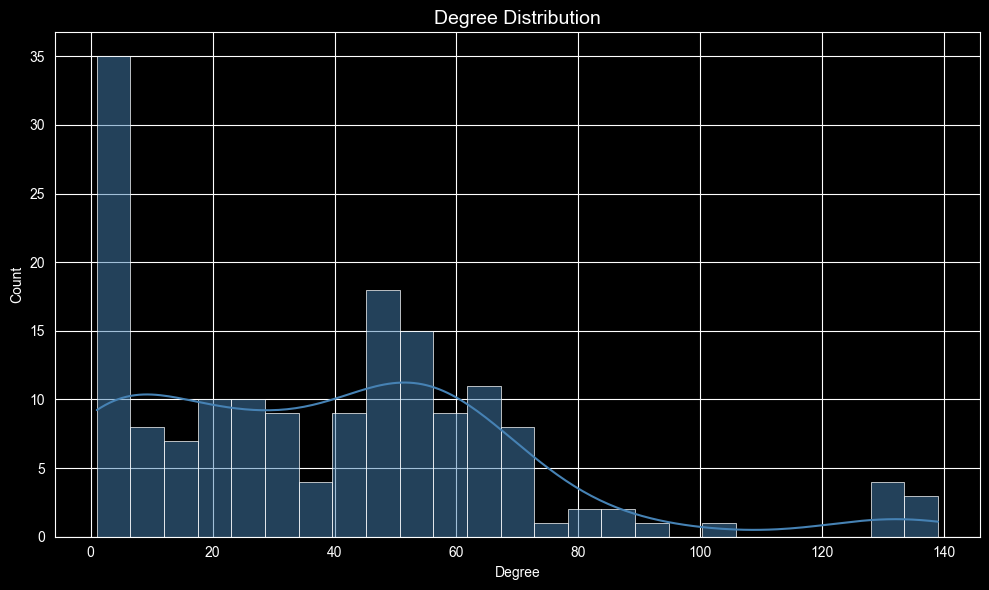

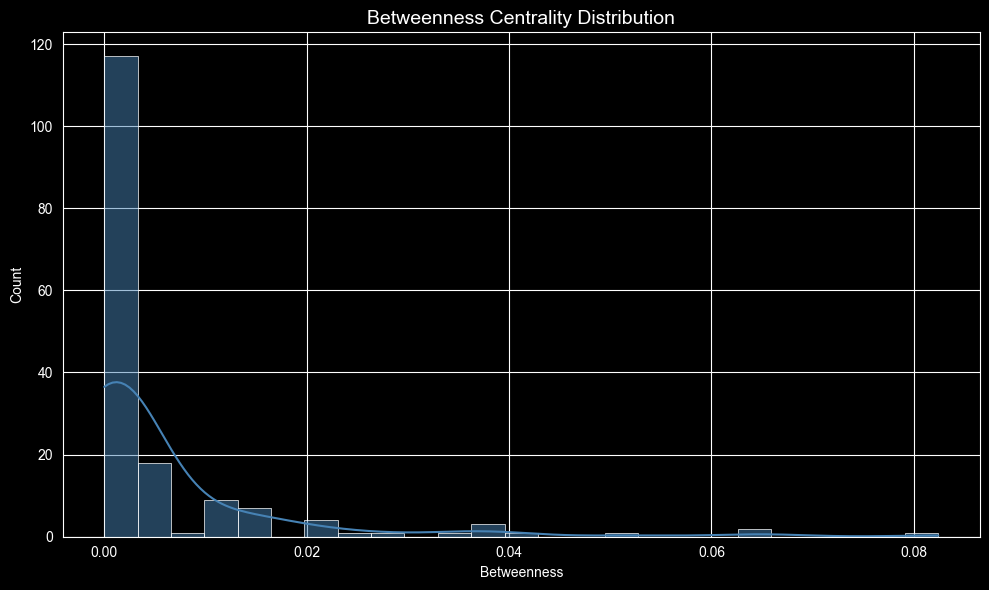

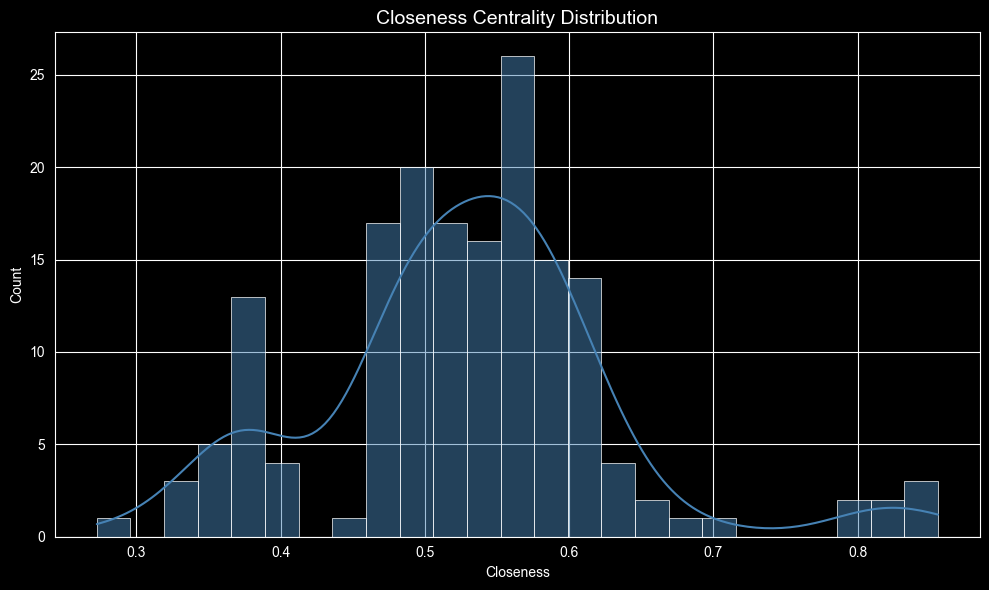

Korelacja Kendall τ:
degree vs betweenness: 0.8042256182614058
degree vs closeness: 0.950852791382257
betweenness vs closeness: 0.7839475424697699
Top degree:
[np.int64(38), np.int64(37), np.int64(45), np.int64(1), np.int64(47)]
Top betweenness:
[np.int64(38), np.int64(37), np.int64(45), np.int64(47), np.int64(1)]
Top closeness:
[np.int64(38), np.int64(37), np.int64(45), np.int64(1), np.int64(47)]


In [14]:
G_email.plot_degree()
G_email.plot_betweenness_centrality()
G_email.plot_closeness_centrality()
G_email.kendall()
G_email.top_nodes()

(d) Sprawdzono ilość komponentów (connected components) w grafie i
czy przy takiej reprezentacji danych mogą być wierzchołki bez krawędzi

In [15]:
connected = G_email.connected_components()
print(f"Connected components: {connected}")
nodes = G_email.nodes_without_edges()
print(f"Nodes without edges: {nodes}")


Connected components: 1
Nodes without edges: 0


(e) Sprawdzono średnice grafu oraz  średnią długość ścieżki w grafie

In [16]:
diameter, shortest = G_email.diameter_and_shortest_path_length()
print(f"Diameter: {diameter}")
print(f"Shortest path: {shortest}")

Diameter: 5
Shortest path: 1.9673905201644903


(f) Stwórzenie grafu na nowo, ale tym razem jako skierowanego. Ustawienie wag
krawędzi w grafie w taki sposób, aby waga pomiędzy wierzchołkiem
v1 a v2 była wyrażona jako liczba wiadomości wysłanych przez v1 do
v2 w stosunku do wszystkich wiadomości wysłanych przez węzeł v1.

In [17]:
G_email_dir = ImportGraph.get_radoslaw_from_file(directed=True)

(g) Sprawdzenie czy w takim grafie skierowanym można dostać się z każdego
wierzchołka do każdego innego.

In [18]:
G_email_dir.if_strongly_connected()

False

### Dyskusja po Części 2
- **Czytelność i intuicyjność API NetworkX**
    - NetworkX posiada bardzo dobrze opisane API, a większość operacji sprowadza się do jednej linii kodu. Trudniejsze jest zarządzanie MultiGraphami oraz wybór właściwego podzbioru metod dla grafów skierowanych vs. nieskierowanych.
- **Widoczność różnic ER vs BA na wizualizacji**
    - Tak – na wizualizacji BA wyraźnie widoczne są huby (duże węzły), podczas gdy w ER węzły mają podobne rozmiary. W BA sieć ma gwiazdowy charakter wokół hubów, ER wygląda bardziej jednorodnie.
- **Korelacja Kendalla**
    - Współczynniki Kendalla potwierdzają silną korelację rankingów. Węzły wysoko rankingowane w jednej mierze centralności są z reguły wysoko też w pozostałych, choć nie jest to reguła bezwyjątkowa – betweenness może wyróżniać węzły-mosty o niskim stopniu.
- **Wpływ kierunkowości na długości ścieżek:**
    - Graf skierowany może być niespójny silnie nawet gdy jego wersja nieskierowana jest spójna – jednostronne krawędzie „odcinają" pewne trasy. Średnie długości ścieżek w grafach silnie spójnych skierowanych są porównywalne z nieskierowanymi, jednak zakres osiągalności jest znacznie ograniczony.